# 公開データの再分析 2: 歩行の力学量と筋活動の妥当性検討

OpenCap のパイプラインが歩行で出力する力学量と筋活動を、公開妥当化データの参照計測と対置するノートブックです。

## 目的

参照計測のない実行例に代えて、同じパイプラインが歩行で出力する床反力、底屈モーメント、筋活動を参照計測と対置し、タイミングと値の対応を確かめます。

## データ

Uhlrich et al. (2023) の実験室妥当化データセット `LabValidation_withoutVideos`（取得方法は `joint_angles.ipynb` と同じ）のうち、次を用います。

- `subject*/OpenSimData/Video/HRNet/2-cameras/Dynamics/walking_results.npy`: 著者らが各歩行試行について公開している OpenSimAD の出力（`sim`）と参照値（`ref`）。床反力（%BW）、関節モーメント、筋活動、骨盤位置を含む。設定はメッシュ密度 100、ローパスフィルタ 6 Hz。
- `subject*/EMGData/<trial>_EMG.sto`: 筋電図（帯域通過・整流・6 Hz ローパスの後に最大活動試行で正規化）。前脛骨筋は左脚のみ。

## 方法

- 10 名の通常歩行各 3 試行（試行名は walking1〜4 のいずれか。体幹動揺条件 walkingTS* は除く）。歩行周期の事象は歩行分析で標準とされるフォースプレートの閾値法（Zeni et al. (2008, Gait & Posture 27: 710–714)）で定める: 踵接地 = 鉛直床反力が 20 N を上回った最初の時刻、離地 = その後 20 N を下回った最初の時刻、立脚期 = 踵接地から離地まで（20 N は同文献がトレッドミル歩行で用いた値。各被験者の体重で %BW に換算）。各試行・各脚の最長の立脚期のうち、全体が記録に含まれる（試行の両端に接しない）ものだけを用いる（29 試行 37 歩）。
- 参照計測はフォースプレート、光学式モーションキャプチャとフォースプレートに基づく逆動力学、筋電図。
- 床反力とモーメントの平均絶対差は立脚期内で算出する。筋活動の相関は、筋電図と OpenSimAD が出力する筋活性化の時系列の試行全体にわたるピアソン相関係数。
- 股関節屈曲モーメントの 10 ms 当たりの変化量の最大値は試行全体で求め、その時刻がいずれかの足の踵接地または離地（上の閾値による）から 0.1 s 以内にあるかを数える（支持脚の交代時に現れる股関節モーメントのピークの検討）。
- 記録は 1 試行につき 1 歩で、歩行速度、筋骨格モデルの版、メッシュ密度が実行例と異なるため、この結果は実行例の値そのものの検証ではない。


In [1]:
import os, sys, platform, numpy as np, pandas as pd
import matplotlib.pyplot as plt
HERE = os.path.abspath('.'); sys.path.insert(0, os.path.join(HERE, 'scripts'))
DATA_DIR = os.environ.get('LABVALIDATION_DIR', os.path.join(HERE, 'data', 'LabValidation_withoutVideos'))
HAVE_DATA = os.path.isdir(os.path.join(DATA_DIR, 'subject2'))
print('Python', platform.python_version(), '| numpy', np.__version__, '| pandas', pd.__version__)
print('データの場所:', DATA_DIR, '| 利用可能:', HAVE_DATA)

Python 3.11.17 | numpy 2.4.6 | pandas 3.0.6
データの場所: /data/LabValidation_withoutVideos | 利用可能: True


## 1. 解析の実行（データがある場合）

`scripts/walking_kinetics.py` の `analyze()` を呼び、立脚期ごとの表 `df`（37 行）と要約表 `summ`（平均・SD・n）を得て `results/` に保存します。データがない場合は同梱の結果を読み込みます。

In [2]:
if HAVE_DATA:
    from walking_kinetics import analyze
    df, summ, settings = analyze(DATA_DIR)
    os.makedirs('results', exist_ok=True)
    df.to_csv('results/walking_kinetics_stances.csv', index=False); summ.to_csv('results/walking_kinetics_summary.csv')
    print('公開出力の設定 (meshDensity, cutoff_freq_coord):', settings)
else:
    df = pd.read_csv('results/walking_kinetics_stances.csv'); summ = pd.read_csv('results/walking_kinetics_summary.csv', index_col=0)
    print('同梱の結果を読み込みました')
print('立脚期 %d 歩（被験者 %d 名、%d 試行、右 %d、左 %d）' % (len(df), df.subject.nunique(), df.groupby(['subject', 'trial']).ngroups, (df.side == 'r').sum(), (df.side == 'l').sum()))

公開出力の設定 (meshDensity, cutoff_freq_coord): [('100', '6')]
立脚期 37 歩（被験者 10 名、29 試行、右 8、左 29）


## 2. 対応表の再構成

値は 37 歩（前脛骨筋は左脚 29 歩）の平均 ± 標準偏差。「計測値」はフォースプレート、逆動力学、筋電図、「OpenSimAD の出力」は公開されている力学シミュレーションの出力です。

In [3]:
def ms(k): return '%.0f ± %.0f' % (summ.loc[k, 'mean'], summ.loc[k, 'sd'])
def corr(k): return '%.2f ± %.2f' % (summ.loc[k, 'mean'], summ.loc[k, 'sd'])
rows = [('鉛直床反力のピーク (% BW)', ms('vgrf_peak_ref_bw'), ms('vgrf_peak_sim_bw'), '---', int(summ.loc['vgrf_peak_ref_bw', 'n'])),
        ('底屈モーメントの極小の値 (Nm)', ms('ankle_min_ref_nm'), ms('ankle_min_sim_nm'), '---', int(summ.loc['ankle_min_ref_nm', 'n'])),
        ('底屈モーメントの極小の時刻 (立脚期の %)', ms('ankle_min_pct_ref'), ms('ankle_min_pct_sim'), '---', int(summ.loc['ankle_min_pct_ref', 'n'])),
        ('股関節屈曲モーメントの 10 ms 当たりの変化量の最大値 (Nm)', ms('hip_rate_ref_nm'), ms('hip_rate_sim_nm'), '---', int(summ.loc['hip_rate_ref_nm', 'n'])),
        ('ヒラメ筋のピーク時刻 (立脚期の %)', ms('soleus_peak_pct_emg'), ms('soleus_peak_pct_sim'), corr('soleus_corr'), int(summ.loc['soleus_corr', 'n'])),
        ('腓腹筋内側頭のピーク時刻 (立脚期の %)', ms('gasmed_peak_pct_emg'), ms('gasmed_peak_pct_sim'), corr('gasmed_corr'), int(summ.loc['gasmed_corr', 'n'])),
        ('前脛骨筋のピーク時刻 (立脚期の %、左脚)', ms('tibant_peak_pct_emg'), ms('tibant_peak_pct_sim'), corr('tibant_corr'), int(summ.loc['tibant_corr', 'n']))]
tab7 = pd.DataFrame(rows, columns=['量', '計測値', 'OpenSimAD の出力', '相関', 'n']).set_index('量')
pd.set_option('display.width', 200); display(tab7)
n_near = int(round(summ.loc['hip_rate_sim_near_transition', 'mean'] * summ.loc['hip_rate_sim_near_transition', 'n']))
display(pd.DataFrame({'値': ['%.1f ± %.1f' % (summ.loc['vgrf_mae_bw', 'mean'], summ.loc['vgrf_mae_bw', 'sd']), '%.0f ± %.0f' % (summ.loc['ankle_mae_nm', 'mean'], summ.loc['ankle_mae_nm', 'sd']), '%d / %d' % (n_near, int(summ.loc['hip_rate_sim_near_transition', 'n']))]},
                     index=['鉛直床反力の立脚期内平均絶対差 (% BW)', '底屈モーメントの立脚期内平均絶対差 (Nm)', '股関節屈曲モーメントの変化量の最大値が支持脚の交代から 0.1 s 以内の歩数']))

,計測値,OpenSimAD の出力,相関,n
量,,,,
鉛直床反力のピーク (% BW),110 ± 5,118 ± 9,---,37
底屈モーメントの極小の値 (Nm),-91 ± 20,-106 ± 19,---,37
底屈モーメントの極小の時刻 (立脚期の %),75 ± 1,82 ± 2,---,37
股関節屈曲モーメントの 10 ms 当たりの変化量の最大値 (Nm),11 ± 5,47 ± 29,---,37
ヒラメ筋のピーク時刻 (立脚期の %),83 ± 5,84 ± 3,0.68 ± 0.18,37
腓腹筋内側頭のピーク時刻 (立脚期の %),78 ± 6,83 ± 5,0.60 ± 0.19,37
前脛骨筋のピーク時刻 (立脚期の %、左脚),22 ± 8,29 ± 24,0.30 ± 0.29,29


,値
鉛直床反力の立脚期内平均絶対差 (% BW),10.5 ± 2.1
底屈モーメントの立脚期内平均絶対差 (Nm),19 ± 7
股関節屈曲モーメントの変化量の最大値が支持脚の交代から 0.1 s 以内の歩数,34 / 37


## 3. 1 歩の例（データがある場合）

1 試行の立脚期について、鉛直床反力、足関節モーメント、ヒラメ筋の筋電図と出力の活性化を重ねて描きます。横軸は立脚期の %。

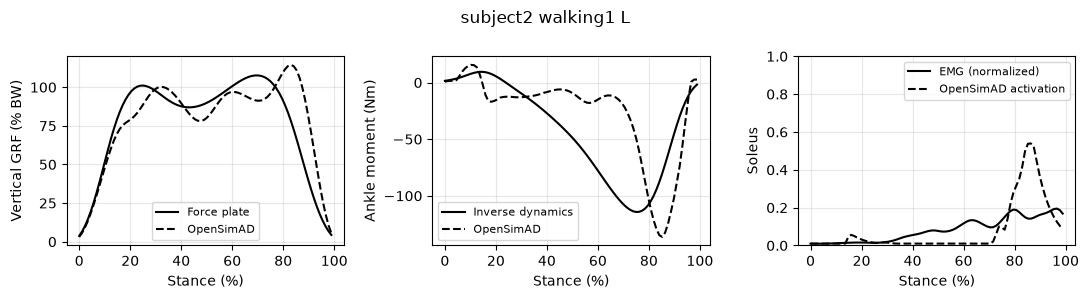

In [4]:
if HAVE_DATA:
    from walking_kinetics import load_trial, stance_window
    sid, trial, side = 'subject2', 'walking1', 'l'
    r, E = load_trial(DATA_DIR, sid, trial)
    g = r['GRFs_BW'][trial]; hg = g['headers']; t = g['ref'][0]
    import yaml; mass = yaml.safe_load(open(os.path.join(DATA_DIR, sid, 'sessionMetadata.yaml')))['mass_kg']
    iy = hg.index(f'ground_force_{side}_vy'); i0, i1 = stance_window(t, g['ref'][iy], 20 / (mass * 9.81) * 100); ts, te = t[i0], t[i1]; m = (t >= ts) & (t < te); x = 100 * (t[m] - ts) / (te - ts)
    q = r['torques'][trial]; ia = q['headers'].index(f'ankle_angle_{side}'); act = r['activations'][trial]; ja = act['headers'].index(f'soleus_{side}')
    e = np.interp(t, E.time.values, E[f'soleus_{side}_activation'].values)
    fig, ax = plt.subplots(1, 3, figsize=(11, 3))
    ax[0].plot(x, g['ref'][iy][m], 'k', label='Force plate'); ax[0].plot(x, g['sim'][iy][m], 'k--', label='OpenSimAD'); ax[0].set_ylabel('Vertical GRF (% BW)')
    ax[1].plot(x, q['ref'][ia][m], 'k', label='Inverse dynamics'); ax[1].plot(x, q['sim'][ia][m], 'k--', label='OpenSimAD'); ax[1].set_ylabel('Ankle moment (Nm)')
    ax[2].plot(x, e[m], 'k', label='EMG (normalized)'); ax[2].plot(x, act['sim'][ja][m], 'k--', label='OpenSimAD activation'); ax[2].set_ylabel('Soleus'); ax[2].set_ylim(0, 1)
    for a in ax: a.set_xlabel('Stance (%)'); a.grid(alpha=.3); a.legend(fontsize=8)
    fig.suptitle(f'{sid} {trial} {side.upper()}'); fig.tight_layout(); plt.show()
else:
    print('データがないため省略します')

## 備考

- `results/walking_kinetics_stances.csv` は立脚期ごとの指標（37 行）、`results/walking_kinetics_summary.csv` はその平均・SD・n です。
- コマンドラインから実行する場合: `LABVALIDATION_DIR=/path/to/LabValidation_withoutVideos python3 scripts/walking_kinetics.py results`
- 実行例のノートブック（`execution_example/reproduce_example.ipynb`）では、この要約表の計測値をメッシュ密度の比較の参照値として読み込みます。